# Практическое задание: Классификация временных рядов (Time Series Classification)

**Цель обучения:**
Познакомиться с основными парадигмами классификации временных рядов (dictionary-based, shapelet-based, feature-based) и базовыми принципами работы с нейросетевыми архитектурами (1D-CNN) для временных рядов. Научиться применять продвинутые методы извлечения признаков и анализировать результаты их работы.

---

## **Задание №1: Теоретические вопросы**
Ответьте на следующие вопросы кратко (2-3 предложения):

1. В чём принципиальная разница между методами SAX (Symbolic Aggregate approXimation) и SFA (Symbolic Fourier Approximation)? Какой из них лучше справляется с зашумленными данными и почему?
2. Как алгоритм BOSS (Bag-of-SFA Symbols) (или его модификации, например WEASEL) использует концепцию TF-IDF для временных рядов? В чем смысл такого подхода?
3. Что такое shapelet (шейплет) временного ряда? В чем преимущество алгоритма ROCKET по сравнению с классическими методами поиска шейплетов?
4. Модель `catch22` извлекает 22 признака из временного ряда. Зачем использовать фиксированные признаки, если можно обучить глубокую нейросеть (CNN) извлекать их автоматически?
5. Почему сверточные нейронные сети (1D-CNN) эффективны для задач классификации временных рядов? Какую роль в них играют многоветвевые (multi-branch) преобразования (например, Inception Time)?

1. Принципиальное различие заключается в том, что SAX дискретизирует временной ряд во временной области (используя кусочно-постоянную аппроксимацию PAA), а SFA — в частотной области (используя дискретное преобразование Фурье). С зашумленными данными лучше справляется метод SFA. Это связано с тем, что SFA позволяет отбросить высокочастотные коэффициенты, в которых обычно сосредоточен случайный шум, и закодировать только наиболее значимые низкочастотные гармоники.
2. В BOSS и WEASEL скользящее окно разбивает ряд на фрагменты, которые преобразуются в символьные SFA-слова, формируя «мешок слов». Концепция TF-IDF используется для взвешивания этих слов: она понижает значимость паттернов, которые часто встречаются во всей выборке, и выделяет редкие, специфичные для конкретных классов фрагменты. Смысл подхода заключается в том, чтобы сфокусировать классификатор на уникальных локальных особенностях ряда, игнорируя повторяющийся фоновый шум.
3. Шейплет — это короткая подпоследовательность временного ряда, форма которой наиболее репрезентативна для определения принадлежности всего ряда к конкретному классу. Классические методы ищут такие фрагменты путем трудоемкого и вычислительно дорогого перебора всех возможных позиций и длин кандидатов. Алгоритм ROCKET обходит эту проблему, применяя фиксированный набор из тысяч случайных сверточных ядер, что позволяет мгновенно извлекать сопоставимые по информативности признаки без затрат на оптимизационный поиск.
4. Использование фиксированных признаков catch22 целесообразно при ограниченном объеме данных, где глубокая CNN склонна к переобучению из-за огромного числа параметров. Кроме того, признаки catch22 научно обоснованы, легко интерпретируются физически (например, через показатели автокорреляции или распределения амплитуд) и требуют минимальных вычислительных ресурсов. Это делает их оптимальным выбором для быстрых, легковесных и прозрачных моделей, работающих в условиях ограниченных ресурсов.
5. 1D-CNN эффективны, так как операции свертки естественным образом улавливают локальные, инвариантные к временному сдвигу паттерны. Многоветвевые преобразования, такие как InceptionTime, позволяют параллельно обрабатывать сигнал фильтрами с разной шириной ядра свертки. Благодаря этому сеть может одновременно распознавать важные события различной длительности и масштаба времени в рамках одной архитектуры.

 # Часть 2: Практическая реализация и сравнение методов

## **Задание № 2:** Сравнить 3 подхода к классификации временных рядов на простом наборе данных `GunPoint` или любом другом стандартном датасете из библиотеки `sktime`.

**Необходимые библиотеки:**
- `sktime` (понадобится для ROCKET и BOSS/WEASEL)
- `catch22` или пакет `tsfel`
- `numpy`, `pandas`, `sklearn`, `matplotlib`
- `tensorflow` или `pytorch` (для 1D-CNN)

X_train shape: (147, 1, 251)
X_test shape: (64, 1, 251)


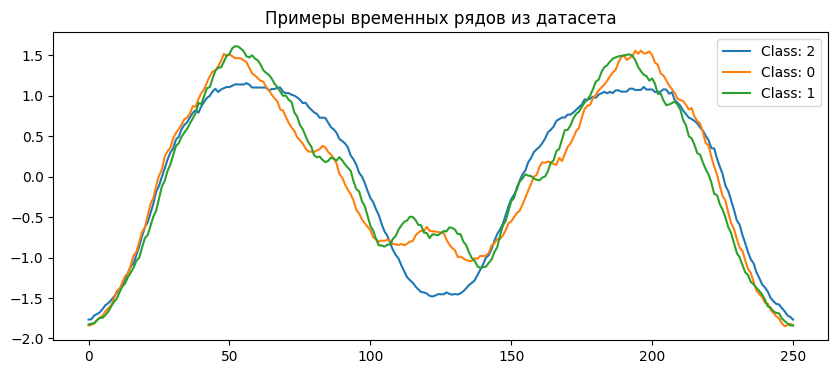

In [2]:
 # Загрузка и подготовка данных
from sktime.datasets import load_arrow_head
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Мы используем датасет ArrowHead (форма наконечников стрел) или любой другой из UCR
X, y = load_arrow_head(return_type="numpy3d")
# X имеет форму (Кол-во образцов, кол-во каналов=1, длина ряда)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

# Отрисовка пары примеров временных рядов разных классов
plt.figure(figsize=(10, 4))
for i in range(3):
    plt.plot(X_train[i, 0, :], label=f"Class: {y_train[i]}")
plt.title("Примеры временных рядов из датасета")
plt.legend()
plt.show()

### Задание 2.1: Классификация с помощью алгоритма ROCKET (Shapelets/Convolutions)

Используйте класс `RocketClassifier` из библиотеки `sktime`. Этот алгоритм генерирует случайные свертки для извлечения признаков и использует Ridge Regression для классификации.

**Задание:**
1. Подключите `RocketClassifier` из `sktime.classification.kernel_based`. Обучите его на `X_train`, `y_train`.
2. Предскажите классы для `X_test` и посчитайте `accuracy_score`. Замерьте время обучения.

In [3]:
%%time
from sktime.classification.kernel_based import RocketClassifier
import time

# Ваш код здесь...
rocket_classifier = RocketClassifier()
rocket_classifier.fit(X_train, y_train)

preds = rocket_classifier.predict(X_test)

accuracy_score(y_test, preds)

CPU times: total: 21.7 s
Wall time: 26 s


0.9375

### Задание № 2.2: Использование алгоритма на основе словарей (Dictionary-based: cBOSS / WEASEL)

Теперь протестируйте класс `BOSSEnsemble` или `ContractableBOSS` из библиотеки `sktime` (раздел `dictionary_based`).
Эти методы преобразуют временные ряды в дискретные слова (алфавит) с использованием скользящего окна (SFA), и оценивают частость.

**Задание:**
1. Подключите любую модель BOSS-семейства.
2. Проведите обучение и вычислите метрику `accuracy_score`. Сравните время обучения с ROCKET.

In [5]:
%%time
from sktime.classification.dictionary_based import ContractableBOSS

# Ваш код здесь...
cboss = ContractableBOSS()
cboss.fit(X_train, y_train)

preds = cboss.predict(X_test)

accuracy_score(y_test, preds)

CPU times: total: 24.3 s
Wall time: 24.9 s


0.96875

### Задание №2.3: Глубокая архитектура для временных рядов (1D-CNN) (с помощью PyTorch)

Создайте простую свёрточную сеть с использованием 1D свёрток. Нейросети для 1D рядов похожи на 2D-сети (картинки), но срез окна проходит вдоль временной оси. Суть использования CNN-архитектур - извлечение сложных локальных и глобальных признаков (features) из формы временного ряда.

**Задание:**
1. Подготовьте данные для фреймворка (PyTorch). 
2. Напишите 2-3 слоя `Conv1D` + `ReLU` + `MaxPooling1D`, затем `Flatten` и выходной слой `Dense` c функцией Softmax.
3. Обучите модель в течение небольшого количества эпох, подсчитайте `accuracy` на тестовом наборе. Сравните с классическими методами (Rocket, BOSS).

In [6]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import time
import matplotlib.pyplot as plt

In [7]:
# 1. Построение простой архитектуры 1D-CNN
class Simple1DCNN(nn.Module):
    def __init__(self, num_classes):
        super(Simple1DCNN, self).__init__()
        # Входной канал = 1 (так как у нас одномерный временной ряд)
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(kernel_size=2)
        
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(kernel_size=2)
        
        self.flatten = nn.Flatten()
        
        # Вычисляем размер после сверток и пулинга (для ArrowHead с длиной 251)
        # После conv1: 251 - 3 + 1 = 249. pool1: 249 // 2 = 124
        # После conv2: 124 - 3 + 1 = 122. pool2: 122 // 2 = 61
        # Итого: 64 канала * 61 = 3904
        self.fc1 = nn.Linear(64 * 61, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

In [8]:
# ваш код здесь
cnn = Simple1DCNN(len(np.unique(y_train)))
len(np.unique(y_train))

3

In [9]:
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.LongTensor(y_train.astype(float))
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.LongTensor(y_test.astype(float))

In [10]:
train_ds = TensorDataset(X_train_t, y_train_t)
test_ds = TensorDataset(X_test_t, y_test_t)

In [11]:
train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=32,
    shuffle=False
)

In [12]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn.parameters())

In [13]:
def train(model, loader, optimizer, loss_fn):
    model.train()
    for X, y in loader:
        optimizer.zero_grad()

        logits = model(X)
        loss = loss_fn(logits, y)

        loss.backward()
        optimizer.step()

In [14]:
def test(model, loader):
    correct = 0
    num = 0

    model.eval()
    with torch.no_grad():
        for X, y in loader:
            logits = model(X)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == y).sum()
            num += len(X)

    return correct / num

In [15]:
%%time
epochs = 100
accuracies = []

for epoch in range(1, epochs + 1):
    print('-' * 10)
    print(f'Epoch {epoch}')
    train(cnn, train_loader, optimizer, loss_fn)
    accuracy = test(cnn, test_loader)
    accuracies.append(accuracy)
    print(f'Accuracy {accuracy}')

----------
Epoch 1
Accuracy 0.671875
----------
Epoch 2
Accuracy 0.5625
----------
Epoch 3
Accuracy 0.703125
----------
Epoch 4
Accuracy 0.6875
----------
Epoch 5
Accuracy 0.6875
----------
Epoch 6
Accuracy 0.734375
----------
Epoch 7
Accuracy 0.703125
----------
Epoch 8
Accuracy 0.734375
----------
Epoch 9
Accuracy 0.609375
----------
Epoch 10
Accuracy 0.71875
----------
Epoch 11
Accuracy 0.703125
----------
Epoch 12
Accuracy 0.75
----------
Epoch 13
Accuracy 0.734375
----------
Epoch 14
Accuracy 0.765625
----------
Epoch 15
Accuracy 0.765625
----------
Epoch 16
Accuracy 0.75
----------
Epoch 17
Accuracy 0.828125
----------
Epoch 18
Accuracy 0.78125
----------
Epoch 19
Accuracy 0.765625
----------
Epoch 20
Accuracy 0.78125
----------
Epoch 21
Accuracy 0.78125
----------
Epoch 22
Accuracy 0.8125
----------
Epoch 23
Accuracy 0.796875
----------
Epoch 24
Accuracy 0.828125
----------
Epoch 25
Accuracy 0.84375
----------
Epoch 26
Accuracy 0.8125
----------
Epoch 27
Accuracy 0.859375
------

Text(0, 0.5, 'Accuracy')

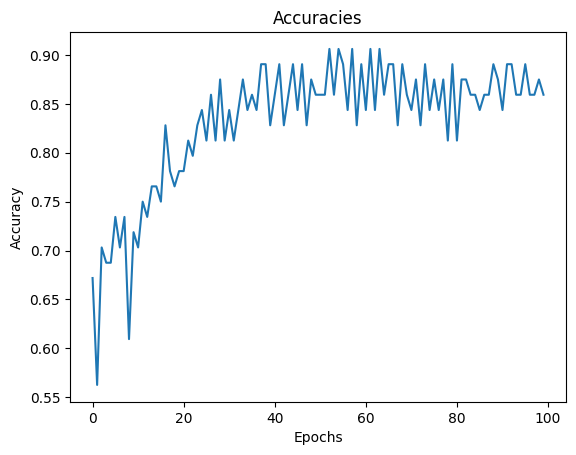

In [16]:
plt.plot(accuracies)
plt.title('Accuracies')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')